In [191]:
import os
import pandas as pd
import geopandas as gpd
import rasterio
import re
import numpy as np
import matplotlib.pyplot as plt

In [192]:
# user-defined paths
base_dir = '../../../../datos-notebooks/3.global-data-cba/'
ground_data_name = 'ground_data_170226_validation.gpkg'

In [193]:
# derived paths
ground_data_path = os.path.join(base_dir, 'MRT-prediction/ground_data', ground_data_name)
mrt_path = os.path.join(base_dir, 'MRT-prediction/MRT_1m.tif')

#### reading and fixing ground data 

In [194]:
gdf = gpd.read_file(ground_data_path)
len(gdf)

C:\Users\guada\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:198: RuntimeWarning:

Non-conformant content for record 1 in column start, 2026-02-17T13:38:25.282-03:00, successfully parsed



26

In [195]:
# correct TG1
# Create corrected TG column based on instrument type
gdf["tg_corr"] = np.where(
    gdf["Instrument"] == "T1 - Sper Scientific 800036 ",
    0.628 * gdf["TG"] + 9.732,   # apply correction for old instrument
    gdf["TG"]                   # keep original value for new instrument
)

In [196]:
gdf.head(3)

,start,end,today,operador,Instrument,condition,TA,TG,WIND M/S,_Location_latitude,_Location_longitude,_Location_altitude,_Location_precision,picture 1,picture 1_URL,picture 2,picture 2_URL,geometry,tg_corr
0,2026-02-17 13:38:25.282000-03:00,2026-02-17 13:40:22.997000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SHADOW,28.7,31.6,2.7,-31.370683,-64.248834,418.516928,4.985490,image-13_40_8.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,image-13_40_19.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,POINT (-64.24834 -31.36998),31.6000
1,2026-02-17 13:18:53.548000-03:00,2026-02-17 13:41:19.664000-03:00,2026-02-16,Macarena,T1 - Sper Scientific 800036,SHADOW,29.3,32.6,0.0,-31.370702,-64.248856,436.989990,37.895014,image-13_40_38.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,image-13_40_47.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,POINT (-64.24836 -31.36995),30.2048
2,2026-02-17 13:40:23.037000-03:00,2026-02-17 13:44:25.264000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SUN,30.1,38.7,1.6,-31.370693,-64.248813,419.412069,6.055630,image-13_44_10.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,image-13_44_18.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,POINT (-64.24881 -31.37069),38.7000


In [197]:
# Parameters
eps = 0.95
D1 = 0.04   # diameter of globe 1 [m] 
D2 = 0.05  # diameter of globe 2 [m] 

# Select diameter according to instrument
D = np.where(gdf["Instrument"] == "T1 - Sper Scientific 800036 ", D1,D2)

# MRT calculation using row-specific diameter
# wind used 0.1 for all cases because values were introducing errores and the changes are not significant (all under 1 m/s)
gdf["MRT"] = (
    (
        (gdf["tg_corr"] + 273.15)**4
        + (1.1e8 * 0.1**0.6 / (eps * D**0.4)) * (gdf["tg_corr"] - gdf["TA"]) 
    )**0.25
    - 273.15
)

Probando con MRT dif 10C sombra

In [198]:
# read raster crs and sample values
with rasterio.open(mrt_path) as src:
    mrt_crs = src.crs
    points_proj = gdf.to_crs(mrt_crs)
    samples = list(src.sample(zip(points_proj.geometry.x, points_proj.geometry.y)))
    points_proj['MRT_predicted'] = [s[0] for s in samples]

points_proj['MRT_predicted'] = points_proj['MRT_predicted'].astype(float) 

# METRICS
obs = points_proj['MRT']
pred = points_proj['MRT_predicted']

points_proj['residual'] = pred - obs

# export gpkg
out_gpkg = os.path.join(base_dir, 'MRT-prediction/MRT_points_2026.gpkg')
points_proj.to_file(out_gpkg, driver="GPKG")

In [199]:
points_proj.head()

,start,end,today,operador,Instrument,condition,TA,TG,WIND M/S,_Location_latitude,...,_Location_precision,picture 1,picture 1_URL,picture 2,picture 2_URL,geometry,tg_corr,MRT,MRT_predicted,residual
0,2026-02-17 13:38:25.282000-03:00,2026-02-17 13:40:22.997000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SHADOW,28.7,31.6,2.7,-31.370683,...,4.985490,image-13_40_8.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,image-13_40_19.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,POINT (381284.173 6528720.501),31.6000,34.039921,41.812473,7.772552
1,2026-02-17 13:18:53.548000-03:00,2026-02-17 13:41:19.664000-03:00,2026-02-16,Macarena,T1 - Sper Scientific 800036,SHADOW,29.3,32.6,0.0,-31.370702,...,37.895014,image-13_40_38.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,image-13_40_47.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,POINT (381282.355 6528723.634),30.2048,31.055270,41.787640,10.732369
2,2026-02-17 13:40:23.037000-03:00,2026-02-17 13:44:25.264000-03:00,2026-02-16,Guadalupe,T2 - TM-188D TENMARS,SUN,30.1,38.7,1.6,-31.370693,...,6.055630,image-13_44_10.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,image-13_44_18.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,POINT (381240.071 6528640.976),38.7000,45.320301,52.308060,6.987759
3,2026-02-17 13:41:19.707000-03:00,2026-02-17 13:45:54.242000-03:00,2026-02-16,Macarena,T1 - Sper Scientific 800036,SUN,28.9,42.2,0.7,-31.370663,...,5.133179,image-13_44_34.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,image-13_44_45.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,POINT (381237.656 6528644.274),36.2336,42.562206,52.330524,9.768319
4,2026-02-17 13:45:54.280000-03:00,2026-02-17 13:55:34.771000-03:00,2026-02-16,Macarena,T1 - Sper Scientific 800036,SUN,34.4,38.0,0.2,-31.366038,...,1.963066,image-13_55_19.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,image-13_55_31.jpg,https://kf.kobotoolbox.org/api/v2/assets/aF3fL...,POINT (381888.001 6529164.351),33.5960,32.859336,45.099792,12.240456


In [200]:

mae = np.mean(np.abs(obs - pred))
rmse = np.sqrt(np.mean((obs - pred)**2))
bias = np.mean(pred - obs)

print("MAE:", mae)
print("RMSE:", rmse)
print("Bias:", bias)

MAE: 6.215741684721895
RMSE: 7.148832356443019
Bias: 5.676726141791129


In [201]:
import plotly.express as px
import numpy as np
import pandas as pd

obs = points_proj['MRT']
pred = points_proj['MRT_predicted']

# Compute 1:1 line range
m = min(obs.min(), pred.min())
M = max(obs.max(), pred.max())

# Scatter
fig = px.scatter(
    points_proj,
    x=points_proj['MRT'],
    y=points_proj['MRT_predicted'],
    color="condition",
    hover_data=["TG", "TA","WIND M/S", "Instrument"],
)

# 1:1 line
fig.add_scatter(
    x=[m, M],
    y=[m, M],
    mode="lines",
    name="1:1 line"
)

fig.update_layout(
    xaxis_title="Observed MRT °C",
    yaxis_title="Predicted MRT °C",
    title="points_proj comparison"
)

fig.update_yaxes(scaleanchor="x", scaleratio=1)

fig.show()


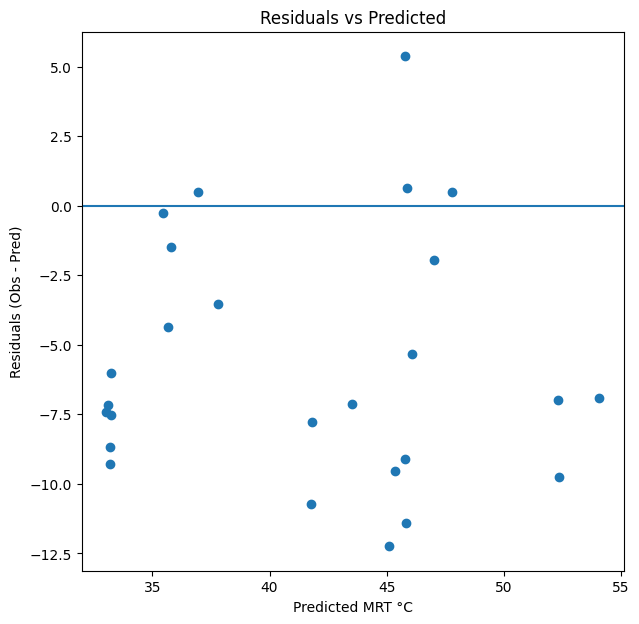

In [202]:
residuals = obs - pred  # Compute residuals

plt.figure(figsize=(7,7))
plt.scatter(pred, residuals)
plt.axhline(0)  # Zero reference line

plt.xlabel("Predicted MRT °C")
plt.ylabel("Residuals (Obs - Pred)")
plt.title("Residuals vs Predicted")
plt.show()


AJUSTANDO MRT PRED

In [203]:
# METRICS
obs = points_proj['MRT']
pred = points_proj['MRT_predicted']-5

points_proj['residual'] = pred - obs



In [204]:

mae = np.mean(np.abs(obs - pred))
rmse = np.sqrt(np.mean((obs - pred)**2))
bias = np.mean(pred - obs)

print("MAE:", mae)
print("RMSE:", rmse)
print("Bias:", bias)

MAE: 3.7852961551586324
RMSE: 4.3975609879358535
Bias: 0.6767261417911291


In [207]:
import plotly.express as px
import numpy as np
import pandas as pd

obs = points_proj['MRT']
pred = points_proj['MRT_predicted']-5

# Compute 1:1 line range
m = min(obs.min(), pred.min())
M = max(obs.max(), pred.max())

# Scatter
fig = px.scatter(
    points_proj,
    x=obs,
    y=pred,
    color="condition",
    hover_data=["TG", "TA","WIND M/S", "Instrument"],
)

# 1:1 line
fig.add_scatter(
    x=[m, M],
    y=[m, M],
    mode="lines",
    name="1:1 line"
)

fig.update_layout(
    xaxis_title="Observed MRT °C",
    yaxis_title="Predicted MRT °C",
    title="points_proj comparison"
)

fig.update_yaxes(scaleanchor="x", scaleratio=1)

fig.show()

In [208]:
obs = points_proj['MRT']
pred = points_proj['MRT_predicted']-5

# Compute 1:1 line range
m = min(obs.min(), pred.min())
M = max(obs.max(), pred.max())

# Scatter
fig = px.scatter(
    points_proj,
    x=obs,
    y=pred,
    color="Instrument",
    hover_data=["TG", "TA","WIND M/S", "condition"],
)

# 1:1 line
fig.add_scatter(
    x=[m, M],
    y=[m, M],
    mode="lines",
    name="1:1 line"
)

fig.update_layout(
    xaxis_title="Observed MRT °C",
    yaxis_title="Predicted MRT °C",
    title="points_proj comparison"
)

fig.update_yaxes(scaleanchor="x", scaleratio=1)

fig.show()

In [209]:
residuals = obs - pred  # Compute residuals
# Scatter
fig = px.scatter(
    points_proj,
    x=pred,
    y=residuals,
    color="Instrument",
    hover_data=["TG", "TA","WIND M/S", "condition"],
)

# 1:1 line
fig.add_scatter(
    x=[pred.min(), pred.max()],
    y=[0, 0],
    mode="lines",
    name="Zero residual line"
)

fig.update_layout(
    xaxis_title="Predicted MRT °C",
    yaxis_title="Residuals (Obs - Pred)",
    title="points_proj residuals"
)

fig.update_yaxes(scaleanchor="x", scaleratio=1)

fig.show()

In [ ]:
# clasificar por zona (usos del suelo)
# justificar el ajuste con datos de radiacion solar